In [57]:
import numpy as np
import matplotlib.pyplot as plt
from rfmodel.core.config import load_yaml
from rfmodel.core.signal import Signal
from rfmodel.core.pipeline_builder import pipeline_from_config
import rfmodel.rf.registry

cfg = load_yaml(r".\PLL_mixer.yaml")
pipe = pipeline_from_config(cfg)

In [58]:
mixer = pipe.get("mixer_and_pll")
mixer.pll = None
mixer.params.mixer_ideal = True

In [59]:
# --- test signal (multi-tone is better than single tone) ---
fs = 10e6
N = 2**14
t = np.arange(N) / fs

x = (
    np.exp(1j * 2*np.pi*100e3*t) +
    0.7 * np.exp(1j * 2*np.pi*300e3*t)
)

sig_in = Signal(x=x, fs_hz=fs, fc_hz=0, meta={})


In [60]:
# --- run through mixer only ---
sig_out = mixer(sig_in)
y = sig_out.x

In [61]:
# --- 1. Power preservation test ---
Pin = np.mean(np.abs(x)**2)
Pout = np.mean(np.abs(y)**2)

print("Input power:", Pin)
print("Output power:", Pout)
print("Power ratio (Pout/Pin):", Pout / Pin)

# ideal expectation: ~1.0
assert np.isclose(Pout / Pin, 1.0, atol=1e-6), "Power not preserved → not ideal"

Input power: 1.4894464584711389
Output power: 1.4894464584711389
Power ratio (Pout/Pin): 1.0


In [62]:
# --- 2. waveform consistency test ---
error = np.mean(np.abs(y - x)**2)
print("MSE:", error)

# ideal expectation: ~0
assert np.isclose(error, 0.0, atol=1e-12), "Waveform changed → not ideal"

# --- 3. frequency domain comparison ---
X = np.fft.fftshift(np.fft.fft(x))
Y = np.fft.fftshift(np.fft.fft(y))

spec_error = np.mean(np.abs(np.abs(X) - np.abs(Y)))
print("Spectral error:", spec_error)

assert np.isclose(spec_error, 0.0, atol=1e-6), "Spectrum changed → not ideal"


MSE: 0.0
Spectral error: 0.0


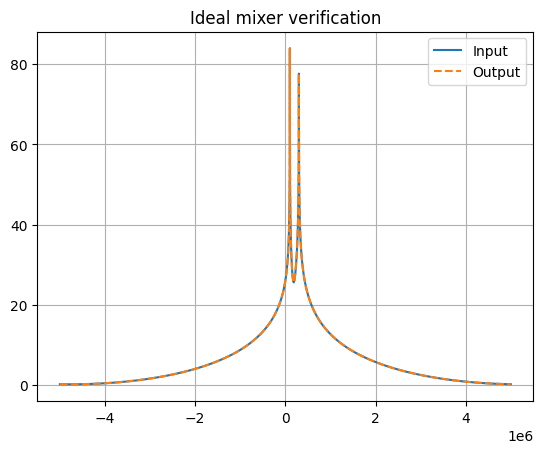

In [63]:
f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))

plt.figure()
plt.plot(f, 20*np.log10(np.abs(X)+1e-12), label="Input")
plt.plot(f, 20*np.log10(np.abs(Y)+1e-12), "--", label="Output")
plt.legend()
plt.grid()
plt.title("Ideal mixer verification")
plt.show()